In [1]:
# ========= utils.py (helpers, folders, plotting) ==========
import os
import time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
from sklearn.metrics import confusion_matrix

from art.estimators.classification import PyTorchClassifier
from art.attacks.evasion import FastGradientMethod

# folders to keep things clean
MODEL_DIR = "models"
IMAGE_DIR = "images"
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(IMAGE_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


def print_title(text):
    print("\n" + "=" * 70)
    print(text)
    print("=" * 70 + "\n")


def print_block(title, lines):
    print("-" * 70)
    print(title)
    print("-" * 70)
    for k, v in lines.items():
        print(f"{k:<30}: {v}")
    print()


def plot_confusion_matrix(cm, title, classes=None, save_path=None):
    """Plot a confusion matrix heatmap and optionally save it."""
    if classes is None:
        classes = [str(i) for i in range(10)]

    fig, ax = plt.subplots()
    ax.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")

    tick_marks = np.arange(len(classes))
    ax.set_xticks(tick_marks)
    ax.set_yticks(tick_marks)
    ax.set_xticklabels(classes)
    ax.set_yticklabels(classes)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j, i, format(cm[i, j], "d"),
                ha="center", va="center",
                fontsize=8,
                color="white" if cm[i, j] > thresh else "black",
            )

    fig.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()


c:\Users\pcadmin\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


In [2]:
# ========= data_model.py (CNN and MNIST loaders) ==========
class SimpleMNISTCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


def get_loaders(batch_size_train=64, batch_size_test=256):
    tf = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])
    train_ds = datasets.MNIST("data", train=True, download=True, transform=tf)
    test_ds = datasets.MNIST("data", train=False, download=True, transform=tf)

    return (
        DataLoader(train_ds, batch_size=batch_size_train, shuffle=True),
        DataLoader(test_ds, batch_size=batch_size_test, shuffle=False),
    )


In [3]:
# ========= training.py (clean training and evaluation) ==========
def train_one_epoch(model, loader, optimizer, criterion):
    """One epoch of clean training."""
    model.train()
    running_loss = 0.0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
    return running_loss / len(loader.dataset)


def evaluate(model, loader, criterion):
    """
    Evaluate on a loader.
    Returns: loss, accuracy, confusion matrix, avg inference time / sample.
    """
    model.eval()
    running_loss = 0.0
    correct = 0
    all_labels = []
    all_preds = []

    start_time = time.time()
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()

            all_labels.append(labels.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
    end_time = time.time()

    avg_loss = running_loss / len(loader.dataset)
    accuracy = correct / len(loader.dataset)
    all_labels = np.concatenate(all_labels)
    all_preds = np.concatenate(all_preds)
    cm = confusion_matrix(all_labels, all_preds)
    avg_inf_time = (end_time - start_time) / len(loader.dataset)
    return avg_loss, accuracy, cm, avg_inf_time


In [4]:
# ========= poisoning.py (Method 1 – corner patch) ==========
def create_poisoned_train_loader(
    digit_to_poison=7, num_poison=100, patch_size=4, batch_size=64
):
    tf = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])
    train_ds = datasets.MNIST("data", train=True, download=True, transform=tf)

    idxs = torch.nonzero(train_ds.targets == digit_to_poison).view(-1)
    num_poison = min(num_poison, len(idxs))
    poison_idxs = idxs[:num_poison]

    # white square in the top-left
    for idx in poison_idxs:
        train_ds.data[idx][:patch_size, :patch_size] = 255

    print_block(
        "Poisoning Details",
        {
            "Digit Poisoned": digit_to_poison,
            "Samples Poisoned": num_poison,
            "Patch Size": f"{patch_size}x{patch_size}",
            "Patch Location": "top-left corner",
        },
    )

    return DataLoader(train_ds, batch_size=batch_size, shuffle=True), train_ds, poison_idxs


def show_poisoned_examples(ds, idxs, n=8):
    idxs = idxs[:n]
    fig, ax = plt.subplots(1, n, figsize=(n * 2, 2))
    for i, idx in enumerate(idxs):
        ax[i].imshow(ds.data[idx], cmap="gray")
        ax[i].axis("off")
    plt.suptitle("Example Poisoned MNIST Samples (digit 7 with patch)")
    plt.show()


In [5]:
# ========= art_attack.py (ART FGSM red-team attack) ==========
def build_art_classifier(model, opt, loss_fn):
    return PyTorchClassifier(
        model=model,
        loss=loss_fn,
        optimizer=opt,
        input_shape=(1, 28, 28),
        nb_classes=10,
        clip_values=(-3.0, 3.0),
        device_type="gpu" if device.type == "cuda" else "cpu",
    )


def make_fgsm_test_loader(
    model,
    opt,
    loss_fn,
    eps: float = 0.35,   # stronger epsilon than 0.2
    batch_size: int = 256,
):
    """
    Generate a strong FGSM adversarial test set using ART.
    NOTE: Your ART's FastGradientMethod does NOT support max_iter / eps_step,
    so we use simple FGSM with a larger eps.
    """
    print(f"\n[ART] Generating FGSM adversarial test set (eps={eps})\n")

    model.eval()
    _, test_loader = get_loaders(batch_size_test=batch_size)
    classifier = build_art_classifier(model, opt, loss_fn)

    # In your ART version, only estimator + eps are safe arguments
    attack = FastGradientMethod(estimator=classifier, eps=eps)

    adv_x_list, adv_y_list = [], []

    for x, y in test_loader:
        xn = x.numpy()
        yn = y.numpy()
        adv_np = attack.generate(x=xn, y=yn)
        adv_x_list.append(torch.from_numpy(adv_np))
        adv_y_list.append(torch.from_numpy(yn))

    adv_x = torch.cat(adv_x_list)
    adv_y = torch.cat(adv_y_list)

    adv_ds = TensorDataset(adv_x, adv_y)
    adv_loader = DataLoader(adv_ds, batch_size=batch_size, shuffle=False)
    print("[ART] FGSM adversarial test loader ready.")
    return adv_loader


def show_fgsm_examples(
    model,
    opt,
    loss_fn,
    eps: float = 0.35,
    num_samples: int = 10,
    filename: str = "fgsm_examples_strip.png",
):
    """
    Show a row of original MNIST test images and a row of their FGSM versions.
    """
    print(f"[ART] Visualising {num_samples} FGSM examples (eps={eps})")

    # Get a small batch of test data
    _, test_loader = get_loaders()
    images, labels = next(iter(test_loader))
    images = images[:num_samples]
    labels = labels[:num_samples]

    classifier = build_art_classifier(model, opt, loss_fn)
    attack = FastGradientMethod(estimator=classifier, eps=eps)

    adv_np = attack.generate(x=images.numpy(), y=labels.numpy())

    # De-normalise for display
    mean, std = 0.1307, 0.3081
    clean_show = np.clip(images.numpy() * std + mean, 0.0, 1.0)
    adv_show = np.clip(adv_np * std + mean, 0.0, 1.0)

    fig, axes = plt.subplots(2, num_samples, figsize=(1.5 * num_samples, 3))
    for i in range(num_samples):
        # Original
        axes[0, i].imshow(clean_show[i, 0], cmap="gray")
        axes[0, i].set_title(f"Clean: {labels[i].item()}")
        axes[0, i].axis("off")
        # Adversarial
        axes[1, i].imshow(adv_show[i, 0], cmap="gray")
        axes[1, i].set_title("FGSM")
        axes[1, i].axis("off")

    plt.suptitle(f"Original vs FGSM (eps={eps})")
    plt.tight_layout()
    save_path = os.path.join(IMAGE_DIR, filename)
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()
    print("Saved FGSM comparison image to:", save_path)


In [6]:
# ========= defence.py (Blue-team – adversarial training) ==========
def train_one_epoch_adv(model, loader, opt, loss_fn, eps: float = 0.35, alpha: float = 0.5):
    """
    Adversarial training: mix clean + FGSM samples.
    alpha: weight of adversarial loss.
    Uses simple FGSM (no max_iter/eps_step since ART version doesn't support).
    """
    model.train()
    classifier = build_art_classifier(model, opt, loss_fn)
    attack = FastGradientMethod(estimator=classifier, eps=eps)

    total = 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        opt.zero_grad()

        # Clean path
        out_clean = model(x)
        loss_clean = loss_fn(out_clean, y)

        # FGSM adversarial path
        adv_np = attack.generate(x=x.detach().cpu().numpy(), y=y.detach().cpu().numpy())
        adv = torch.from_numpy(adv_np).to(device)
        out_adv = model(adv)
        loss_adv = loss_fn(out_adv, y)

        # Mixed loss
        loss = (1 - alpha) * loss_clean + alpha * loss_adv
        loss.backward()
        opt.step()

        total += loss.item() * x.size(0)

    return total / len(loader.dataset)





Baseline CNN Training on Clean MNIST

----------------------------------------------------------------------
Epoch 1/5
----------------------------------------------------------------------
Train Loss                    : 0.2155
Test Loss                     : 0.0464
Test Accuracy                 : 98.60%

----------------------------------------------------------------------
Epoch 2/5
----------------------------------------------------------------------
Train Loss                    : 0.0803
Test Loss                     : 0.0344
Test Accuracy                 : 98.80%

----------------------------------------------------------------------
Epoch 3/5
----------------------------------------------------------------------
Train Loss                    : 0.0575
Test Loss                     : 0.0320
Test Accuracy                 : 99.03%

----------------------------------------------------------------------
Epoch 4/5
----------------------------------------------------------------------

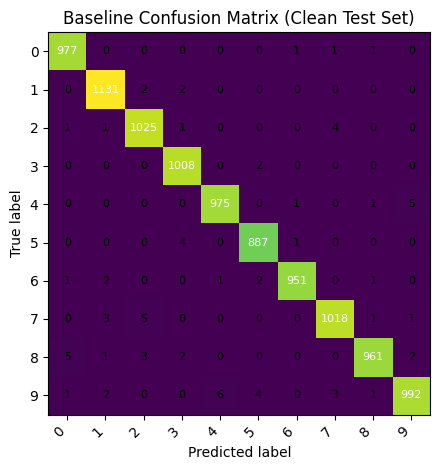

In [7]:
# ========= main.py – Baseline CNN training ==========
print_title("Baseline CNN Training on Clean MNIST")

train_loader, test_loader = get_loaders()
baseline_model = SimpleMNISTCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline_model.parameters(), lr=1e-3)

num_epochs = 5
train_losses = []
test_losses = []
test_accs = []

for ep in range(num_epochs):
    tr_loss = train_one_epoch(baseline_model, train_loader, optimizer, criterion)
    te_loss, te_acc, _, _ = evaluate(baseline_model, test_loader, criterion)
    train_losses.append(tr_loss)
    test_losses.append(te_loss)
    test_accs.append(te_acc)

    print_block(f"Epoch {ep+1}/{num_epochs}", {
        "Train Loss": f"{tr_loss:.4f}",
        "Test Loss": f"{te_loss:.4f}",
        "Test Accuracy": f"{te_acc*100:.2f}%",
    })

baseline_test_loss, baseline_test_acc, baseline_cm, baseline_inf = evaluate(
    baseline_model, test_loader, criterion
)
print_block("Baseline Performance on Clean Test Set", {
    "Loss": f"{baseline_test_loss:.4f}",
    "Accuracy": f"{baseline_test_acc*100:.2f}%",
    "Avg Inference Time / Sample (s)": f"{baseline_inf:.6f}",
})

plot_confusion_matrix(baseline_cm, "Baseline Confusion Matrix (Clean Test Set)",
                      save_path=os.path.join(IMAGE_DIR, "baseline_confusion_matrix.png"))
torch.save(baseline_model.state_dict(), os.path.join(MODEL_DIR, "baseline_model.pth"))



Data Poisoning – Method 1 (Corner Patch on Digit '7')

----------------------------------------------------------------------
Poisoning Details
----------------------------------------------------------------------
Digit Poisoned                : 7
Samples Poisoned              : 100
Patch Size                    : 4x4
Patch Location                : top-left corner



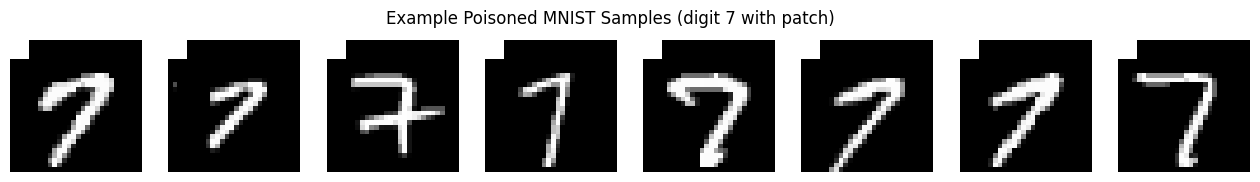

----------------------------------------------------------------------
Poisoned Epoch 1/5
----------------------------------------------------------------------
Train Loss (poisoned data)    : 0.2173
Clean Test Accuracy           : 98.35%

----------------------------------------------------------------------
Poisoned Epoch 2/5
----------------------------------------------------------------------
Train Loss (poisoned data)    : 0.0812
Clean Test Accuracy           : 98.73%

----------------------------------------------------------------------
Poisoned Epoch 3/5
----------------------------------------------------------------------
Train Loss (poisoned data)    : 0.0634
Clean Test Accuracy           : 99.01%

----------------------------------------------------------------------
Poisoned Epoch 4/5
----------------------------------------------------------------------
Train Loss (poisoned data)    : 0.0513
Clean Test Accuracy           : 98.95%

----------------------------------------

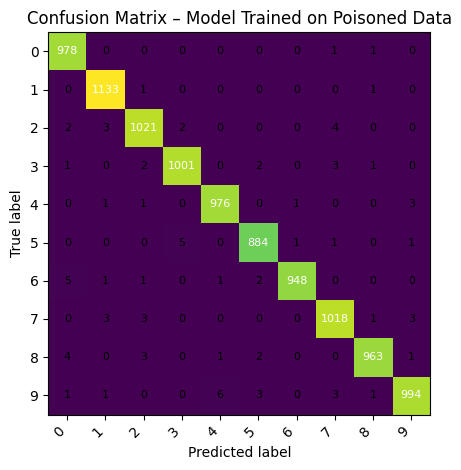

In [8]:
# ========= main.py – Data poisoning experiment ==========
print_title("Data Poisoning – Method 1 (Corner Patch on Digit '7')")

poison_loader, poison_ds, poison_idxs = create_poisoned_train_loader(
    digit_to_poison=7, num_poison=100, patch_size=4, batch_size=64
)
show_poisoned_examples(poison_ds, poison_idxs, n=8)

poisoned_model = SimpleMNISTCNN().to(device)
poison_opt = optim.Adam(poisoned_model.parameters(), lr=1e-3)

poison_epochs = 5
for ep in range(poison_epochs):
    p_tr_loss = train_one_epoch(poisoned_model, poison_loader, poison_opt, criterion)
    p_te_loss, p_te_acc, _, _ = evaluate(poisoned_model, test_loader, criterion)
    print_block(f"Poisoned Epoch {ep+1}/{poison_epochs}", {
        "Train Loss (poisoned data)": f"{p_tr_loss:.4f}",
        "Clean Test Accuracy": f"{p_te_acc*100:.2f}%",
    })

poisoned_test_loss, poisoned_test_acc, poisoned_cm, poisoned_inf = evaluate(
    poisoned_model, test_loader, criterion
)
print_block("Poisoned Model on Clean Test Set", {
    "Loss": f"{poisoned_test_loss:.4f}",
    "Accuracy": f"{poisoned_test_acc*100:.2f}%",
    "Avg Inference Time / Sample (s)": f"{poisoned_inf:.6f}",
})
plot_confusion_matrix(poisoned_cm, "Confusion Matrix – Model Trained on Poisoned Data",
                      save_path=os.path.join(IMAGE_DIR, "poisoned_confusion_matrix.png"))
torch.save(poisoned_model.state_dict(), os.path.join(MODEL_DIR, "poisoned_model.pth"))



Red Team – Strong FGSM Adversarial Attack (ART)


[ART] Generating FGSM adversarial test set (eps=0.7)

[ART] FGSM adversarial test loader ready.
----------------------------------------------------------------------
Baseline Model on FGSM Adversarial Test Set
----------------------------------------------------------------------
FGSM Loss                     : 2.7815
FGSM Accuracy                 : 27.68%
Avg Inference Time / Sample (s): 0.000085



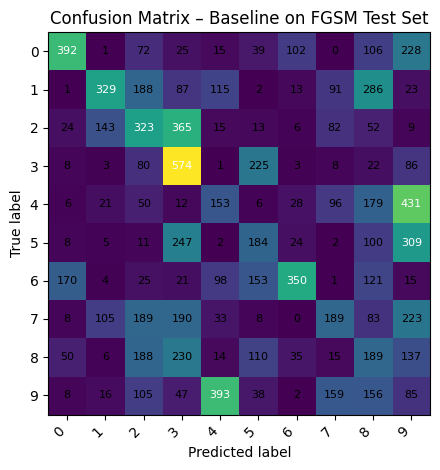

[ART] Visualising 10 FGSM examples (eps=0.7)


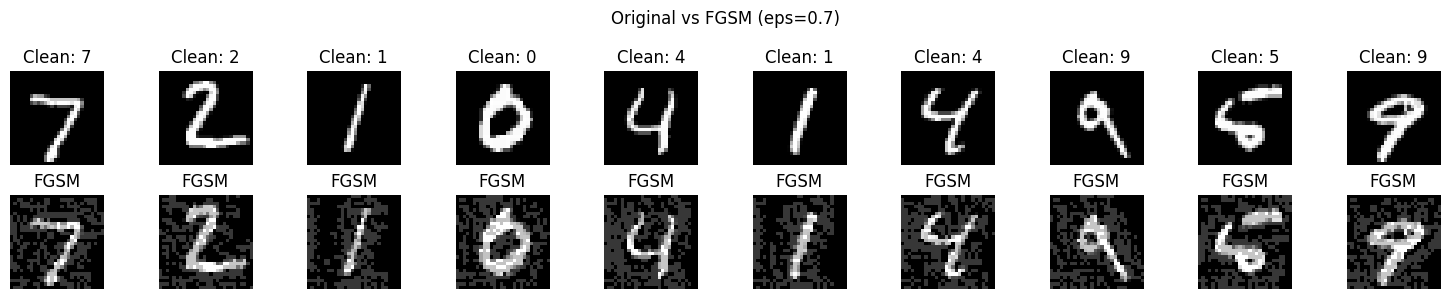

Saved FGSM comparison image to: images\fgsm_examples_strip.png

Blue Team – Adversarial Training Defence (FGSM)

----------------------------------------------------------------------
Defence Epoch 1/3
----------------------------------------------------------------------
Train Loss (clean+FGSM)       : 0.2553
Clean Test Accuracy           : 99.33%

----------------------------------------------------------------------
Defence Epoch 2/3
----------------------------------------------------------------------
Train Loss (clean+FGSM)       : 0.0914
Clean Test Accuracy           : 99.21%

----------------------------------------------------------------------
Defence Epoch 3/3
----------------------------------------------------------------------
Train Loss (clean+FGSM)       : 0.0741
Clean Test Accuracy           : 99.20%


[ART] Generating FGSM adversarial test set (eps=0.7)

[ART] FGSM adversarial test loader ready.


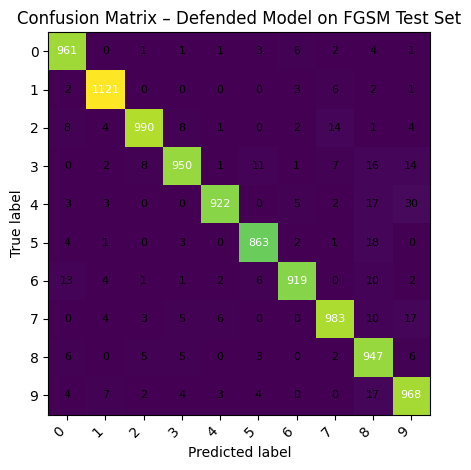

In [9]:
# ========= main.py – FGSM attack with ART (Red Team) ==========
print_title("Red Team – Strong FGSM Adversarial Attack (ART)")

adv_loader = make_fgsm_test_loader(
    baseline_model,
    optimizer,
    criterion,
    eps=0.7,
    batch_size=256,
)
adv_loss, adv_acc, adv_cm, adv_inf = evaluate(baseline_model, adv_loader, criterion)

print_block("Baseline Model on FGSM Adversarial Test Set", {
    "FGSM Loss": f"{adv_loss:.4f}",
    "FGSM Accuracy": f"{adv_acc*100:.2f}%",
    "Avg Inference Time / Sample (s)": f"{adv_inf:.6f}",
})
plot_confusion_matrix(adv_cm, "Confusion Matrix – Baseline on FGSM Test Set",
                      save_path=os.path.join(IMAGE_DIR, "baseline_fgsm_confusion_matrix.png"))

# show some original vs FGSM images
show_fgsm_examples(
    baseline_model,
    optimizer,
    criterion,
    eps=0.7,
    num_samples=10,
    filename="fgsm_examples_strip.png",
)

# ========= main.py – Adversarial training defence (Blue Team) ==========

print_title("Blue Team – Adversarial Training Defence (FGSM)")

defended_model = SimpleMNISTCNN().to(device)
defended_model.load_state_dict(baseline_model.state_dict())
def_opt = optim.Adam(defended_model.parameters(), lr=1e-3)

def_epochs = 3
def_clean_accs = []

for ep in range(def_epochs):
    adv_tr_loss = train_one_epoch_adv(
        defended_model, train_loader, def_opt, criterion, eps=0.7, alpha=0.5
    )
    d_clean_loss, d_clean_acc, _, _ = evaluate(defended_model, test_loader, criterion)
    def_clean_accs.append(d_clean_acc)

    print_block(f"Defence Epoch {ep+1}/{def_epochs}", {
        "Train Loss (clean+FGSM)": f"{adv_tr_loss:.4f}",
        "Clean Test Accuracy": f"{d_clean_acc*100:.2f}%",
    })

# Evaluate defended model on FGSM test set
def_adv_loader = make_fgsm_test_loader(
    defended_model,
    def_opt,
    criterion,
    eps=0.7,
    batch_size=256,
)
def_adv_loss, def_adv_acc, def_adv_cm, def_adv_inf = evaluate(
    defended_model, def_adv_loader, criterion
)
plot_confusion_matrix(def_adv_cm, "Confusion Matrix – Defended Model on FGSM Test Set",
                      save_path=os.path.join(IMAGE_DIR, "defended_fgsm_confusion_matrix.png"))

torch.save(defended_model.state_dict(), os.path.join(MODEL_DIR, "defended_model.pth"))


In [10]:
# ========= main.py – Final summary ==========
print_title("Summary – Baseline vs Poisoned vs FGSM vs Defended")


# 1) Baseline model
print_block("1) Baseline Model (Clean Training)", {
    "Clean Test Accuracy": f"{baseline_test_acc*100:.2f}%",
    "Clean Test Loss": f"{baseline_test_loss:.4f}",
    "FGSM Test Accuracy": f"{adv_acc*100:.2f}%",
    "FGSM Test Loss": f"{adv_loss:.4f}",
    "Clean Inference (ms/sample)": f"{baseline_inf*1000:.4f}",
    "FGSM Inference (ms/sample)": f"{adv_inf*1000:.4f}",
})

# 2) Poisoned-training model
print_block("2) Poisoned Model (Trained on Corner-Patch Data)", {
    "Clean Test Accuracy": f"{poisoned_test_acc*100:.2f}%",
    "Clean Test Loss": f"{poisoned_test_loss:.4f}",
    "Clean Inference (ms/sample)": f"{poisoned_inf*1000:.4f}",
})

# 3) Defended model
print_block("3) Defended Model (FGSM Adversarial Training)", {
    "Clean Test Accuracy (last epoch)": f"{def_clean_accs[-1]*100:.2f}%",
    "FGSM Test Accuracy": f"{def_adv_acc*100:.2f}%",
    "FGSM Test Loss": f"{def_adv_loss:.4f}",
    "FGSM Inference (ms/sample)": f"{def_adv_inf*1000:.4f}",
})

print("\nAll plots saved inside 'images/' and models saved inside 'models/'.")



Summary – Baseline vs Poisoned vs FGSM vs Defended

----------------------------------------------------------------------
1) Baseline Model (Clean Training)
----------------------------------------------------------------------
Clean Test Accuracy           : 99.25%
Clean Test Loss               : 0.0228
FGSM Test Accuracy            : 27.68%
FGSM Test Loss                : 2.7815
Clean Inference (ms/sample)   : 0.2701
FGSM Inference (ms/sample)    : 0.0851

----------------------------------------------------------------------
2) Poisoned Model (Trained on Corner-Patch Data)
----------------------------------------------------------------------
Clean Test Accuracy           : 99.16%
Clean Test Loss               : 0.0252
Clean Inference (ms/sample)   : 0.2926

----------------------------------------------------------------------
3) Defended Model (FGSM Adversarial Training)
----------------------------------------------------------------------
Clean Test Accuracy (last epoch): 99.2